In [3]:
df = pd.read_csv(r"D:\Data Analytics Notes (Webskitters)\Python Projects\Project 2\Trending Movies Over The Years.csv")

In [4]:
df.head()

,Unnamed: 0,id,title,original_title,overview,adult,original_language,popularity,vote_average,vote_count,release_date
0,0,83533,Avatar: Fire and Ash,Avatar: Fire and Ash,In the wake of the devastating war against the...,False,en,499.3595,7.339,2198,2025-12-17
1,1,1171145,Crime 101,Crime 101,When an elusive thief whose high-stakes heists...,False,en,344.8161,6.976,328,2026-02-11
2,2,1226863,The Super Mario Galaxy Movie,The Super Mario Galaxy Movie,Having thwarted Bowser's previous plot to marr...,False,en,252.9603,6.900,123,2026-04-01
3,3,687163,Project Hail Mary,Project Hail Mary,Science teacher Ryland Grace wakes up on a spa...,False,en,244.5877,8.200,928,2026-03-15
4,4,1325734,The Drama,The Drama,A happily engaged couple is put to the test wh...,False,en,38.9768,6.385,48,2026-03-26


In [11]:
df = df.reset_index(drop=True)
df.index = df.index + 1
df.head()

,Unnamed: 0,id,title,original_title,overview,adult,original_language,popularity,vote_average,vote_count,release_date
1,0,83533,Avatar: Fire and Ash,Avatar: Fire and Ash,In the wake of the devastating war against the...,False,en,499.3595,7.339,2198,2025-12-17
2,1,1171145,Crime 101,Crime 101,When an elusive thief whose high-stakes heists...,False,en,344.8161,6.976,328,2026-02-11
3,2,1226863,The Super Mario Galaxy Movie,The Super Mario Galaxy Movie,Having thwarted Bowser's previous plot to marr...,False,en,252.9603,6.900,123,2026-04-01
4,3,687163,Project Hail Mary,Project Hail Mary,Science teacher Ryland Grace wakes up on a spa...,False,en,244.5877,8.200,928,2026-03-15
5,4,1325734,The Drama,The Drama,A happily engaged couple is put to the test wh...,False,en,38.9768,6.385,48,2026-03-26


In [13]:
# OBJECTIVE 1: Top Movies by Popularity
    # Which movies are trending the most (highest popularity score)
top_movies = df.sort_values(by="popularity", ascending=False).head(10)
top_movies[["title", "popularity"]]


,title,popularity
17,Your Heart Will Be Broken,1318.7141
1,Avatar: Fire and Ash,499.3595
15,Mike & Nick & Nick & Alice,363.9071
2,Crime 101,344.8161
24,Shelter,319.7283
11,GOAT,288.6351
26,Pretty Lethal,268.3482
12,Hoppers,261.8200
3,The Super Mario Galaxy Movie,252.9603
4,Project Hail Mary,244.5877


In [14]:
# OBJECTIVE 2: Audience Engagement (Vote Count)
    # Which movies got the highest audience interaction (votes)
top_votes = df.sort_values(by="vote_count", ascending=False).head(10)
top_votes[["title", "vote_count"]]

,title,vote_count
588,Interstellar,39263
922,Inception,38927
486,The Avengers,36905
833,The Dark Knight,35416
426,Avatar,33692
1681,Deadpool,32515
994,Fight Club,31704
879,Avengers: Infinity War,31676
999,Pulp Fiction,29918
2927,Guardians of the Galaxy,29495


In [16]:
# OBJECTIVE 3: Top 5 Best-Rated Movies
    # Which movies have the highest ratings
top_rated = df.sort_values(by="vote_average", ascending=False).head(5)

top_rated[["title", "vote_average"]]

,title,vote_average
3585,The Stillness,10.0
4573,Stillness,10.0
1055,No estás sol@,10.0
5309,Dead or Alive,10.0
4535,Skinjacker,10.0


In [20]:
# OBJECTIVE 4: Top Languages in Movies
    # Which language movies appear most?
lang = df["original_language"].value_counts().head(5)
print(lang)

original_language
en    6011
fr     582
ja     519
zh     390
es     318
Name: count, dtype: int64


In [22]:
# OBJECTIVE 5: Movies with Lowest Votes
    # Find the least popular movies
low_votes = df.sort_values(by="vote_count").head(5)
low_votes[["title", "vote_count"]]

,title,vote_count
2204,Muthu Alias Kaattaan,0
2480,WICKED WONDERLAND 4: THE TICK OF TIME,0
2481,Staatsräson,0
2483,The Convenience Store,0
2484,Bad Slippers,0


In [24]:
# OBJECTIVE 6: Popular Movies with Low Ratings
    # Popular but not highly rated (overhyped movies)
popular_low_rating = df[
    (df["popularity"] > df["popularity"].mean()) & 
    (df["vote_average"] < df["vote_average"].mean())
]

popular_low_rating[["title", "popularity", "vote_average"]].head(5)

,title,popularity,vote_average
20,Michael,18.0453,0.0
22,It Takes a Village,13.4154,4.0
23,The Devil Wears Prada 2,16.3889,0.0
32,Backrooms,19.0527,0.0
36,Lee Cronin's The Mummy,17.4653,0.0


In [25]:
# OBJECTIVE 7: Movies with High Votes but Low Ratings
    # Many people voted but ratings are low
high_votes_low_rating = df[
    (df["vote_count"] > df["vote_count"].mean()) & 
    (df["vote_average"] < df["vote_average"].mean())
]

high_votes_low_rating[["title", "vote_count", "vote_average"]].head(5)

,title,vote_count,vote_average
391,Snow White,1591,4.317
2939,Scary Movie 5,2986,4.792
3904,Ghost Rider: Spirit of Vengeance,4020,5.008
5986,Elektra,2628,5.045
6078,Catwoman,3546,4.618


In [26]:
# Visualization 

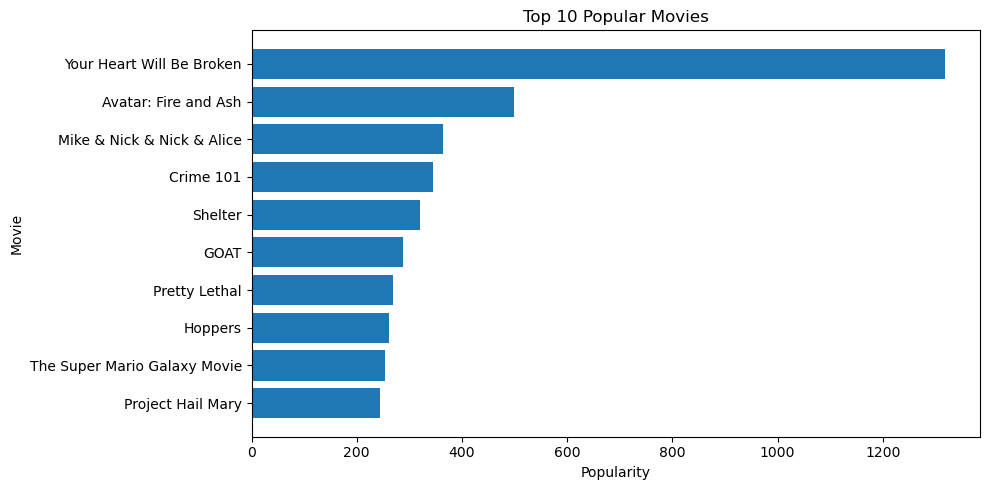

In [27]:
# OBJECTIVE 1: Top Popular Movies
plt.figure(figsize=(10,5))

plt.barh(top_movies["title"], top_movies["popularity"])

plt.title("Top 10 Popular Movies")
plt.xlabel("Popularity")
plt.ylabel("Movie")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

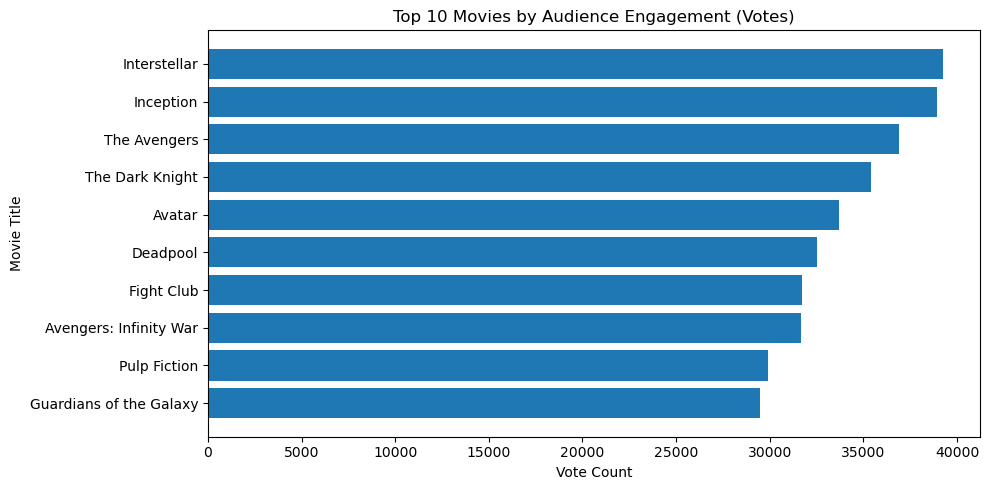

In [28]:
# OBJECTIVE 2: Audience Engagement (Vote Count)
plt.figure(figsize=(10,5))

plt.barh(top_votes["title"], top_votes["vote_count"])

plt.title("Top 10 Movies by Audience Engagement (Votes)")
plt.xlabel("Vote Count")
plt.ylabel("Movie Title")

plt.gca().invert_yaxis()   # highest at top
plt.tight_layout()
plt.show()

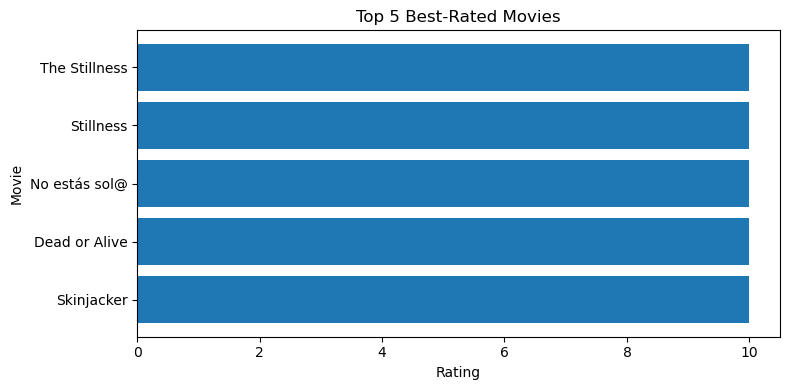

In [29]:
# OBJECTIVE 3: Top 5 Best-Rated Movies
plt.figure(figsize=(8,4))

plt.barh(top_rated["title"], top_rated["vote_average"])

plt.title("Top 5 Best-Rated Movies")
plt.xlabel("Rating")
plt.ylabel("Movie")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

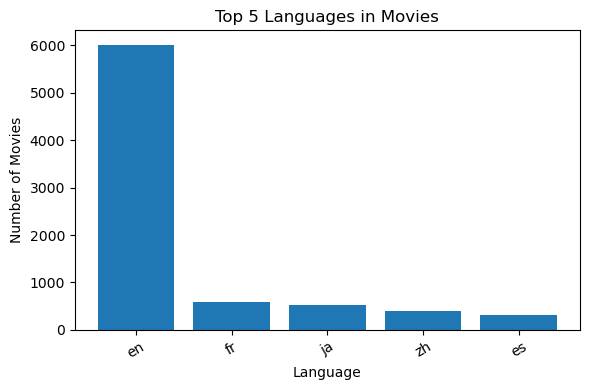

In [30]:
# OBJECTIVE 4: Top Languages in Movies
plt.figure(figsize=(6,4))

plt.bar(lang.index, lang.values)

plt.title("Top 5 Languages in Movies")
plt.xlabel("Language")
plt.ylabel("Number of Movies")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

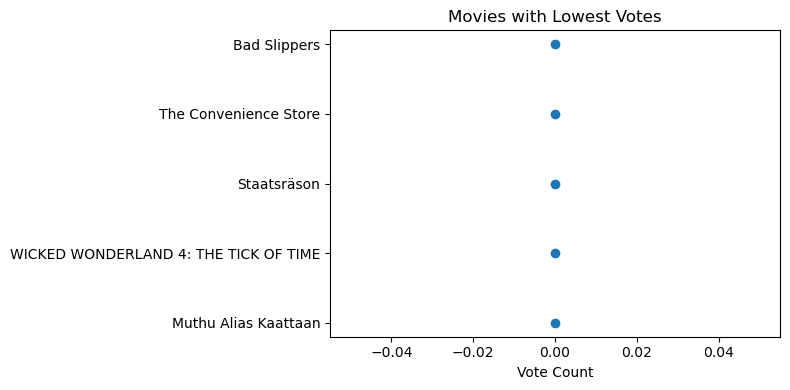

In [33]:
# OBJECTIVE 5: Movies with Lowest Votes
plt.figure(figsize=(8,4))

plt.scatter(low_votes["vote_count"], low_votes["title"])

plt.title("Movies with Lowest Votes")
plt.xlabel("Vote Count")

plt.tight_layout()
plt.show()

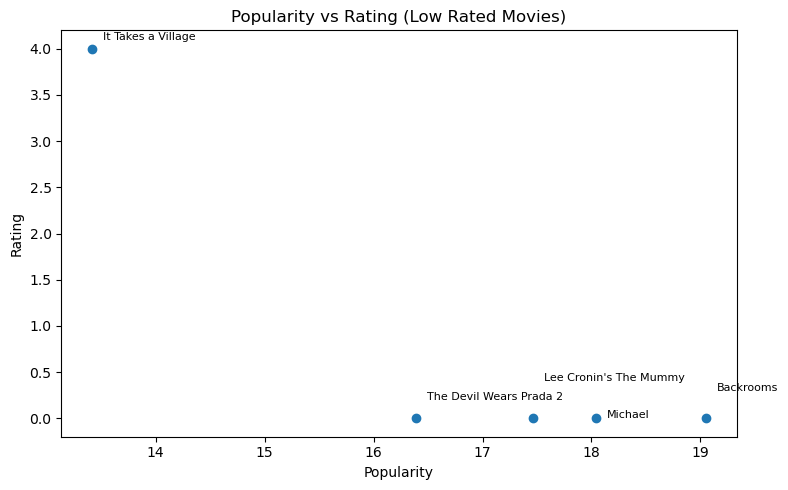

In [37]:
# OBJECTIVE 6: Popular Movies with Low Ratings
plt.figure(figsize=(8,5))

plt.scatter(temp["popularity"], temp["vote_average"])

for i in range(len(temp)):
    plt.text(
        temp["popularity"].iloc[i] + 0.1,
        temp["vote_average"].iloc[i] + (i * 0.1),
        temp["title"].iloc[i],
        fontsize=8
    )

plt.title("Popularity vs Rating (Low Rated Movies)")
plt.xlabel("Popularity")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

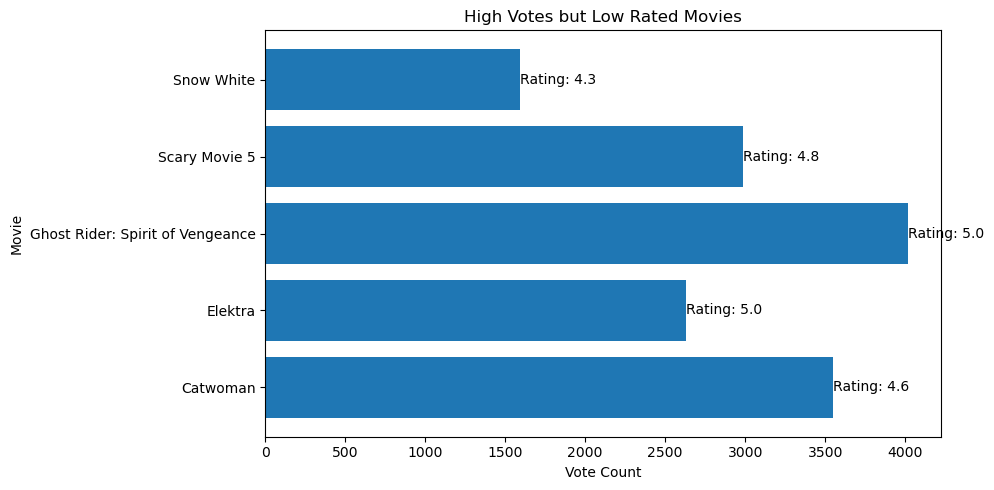

In [38]:
# OBJECTIVE 7: High Votes but Low Ratings
temp3 = high_votes_low_rating.head(5)

plt.figure(figsize=(10,5))

plt.barh(temp3["title"], temp3["vote_count"])

plt.title("High Votes but Low Rated Movies")
plt.xlabel("Vote Count")
plt.ylabel("Movie")

# Add ratings as labels
for i, v in enumerate(temp3["vote_count"]):
    rating = temp3["vote_average"].iloc[i]
    plt.text(v, i, f"Rating: {round(rating,1)}", va='center')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

df = pd.read_csv(r"D:\Data Analytics Notes (Webskitters)\Python Projects\Project 2\Trending Movies Over The Years.csv")